In [1]:
import os

import pandas as pd
import torch
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

base_cmap = plt.get_cmap("tab20")

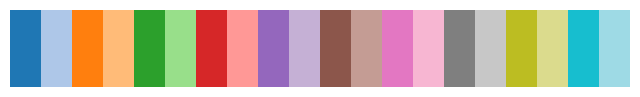

In [2]:
plt.figure(figsize=(8, 1))
plt.imshow([base_cmap(range(base_cmap.N))], aspect="auto")
plt.axis("off")
plt.show()

In [3]:
DATA_BASE = "../Data/enformer_style_split_data_v1"
RES_BASE = "../Res"
exp_name = "250606_finetune_new_data"
chk = 87

os.makedirs(f"{RES_BASE}/{exp_name}/analysis_{chk}/plot", exist_ok=True)
os.makedirs(f"{RES_BASE}/{exp_name}/analysis_{chk}/raw_data", exist_ok=True)

In [4]:
label_meta = pd.read_csv(f"{DATA_BASE}/label_meta.csv", index_col=0)

In [ ]:
for split in ["Train", "Valid", "Test"]:
    test_res = torch.load(f"{RES_BASE}/{exp_name}/{split}_preds_epoch_{chk}.pt")
    test_label = test_res["label"].reshape(-1, len(label_meta))
    test_pred = test_res["pred"].reshape(-1, len(label_meta))

    metric = pd.DataFrame(index=label_meta["trial"], columns=["MSE", "MAE", "PearsonR"])

    for i in tqdm(label_meta.index):
        trail_label = test_label[:, i]
        trail_pred = test_pred[:, i]

        metric.loc[label_meta.loc[i, "trial"]] = (
            mean_squared_error(trail_label, trail_pred),
            mean_absolute_error(trail_label, trail_pred),
            pearsonr(trail_label, trail_pred)[0],
        )

    metric.to_csv(f"{RES_BASE}/{exp_name}/analysis_{chk}/raw_data/{split}_metric.csv")

/tmp/ipykernel_2642175/1020066093.py:2: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

100%|██████████| 93/93 [02:35<00:00,  1.67s/it]
/tmp/ipykernel_2642175/1020066093.py:2:

# plots

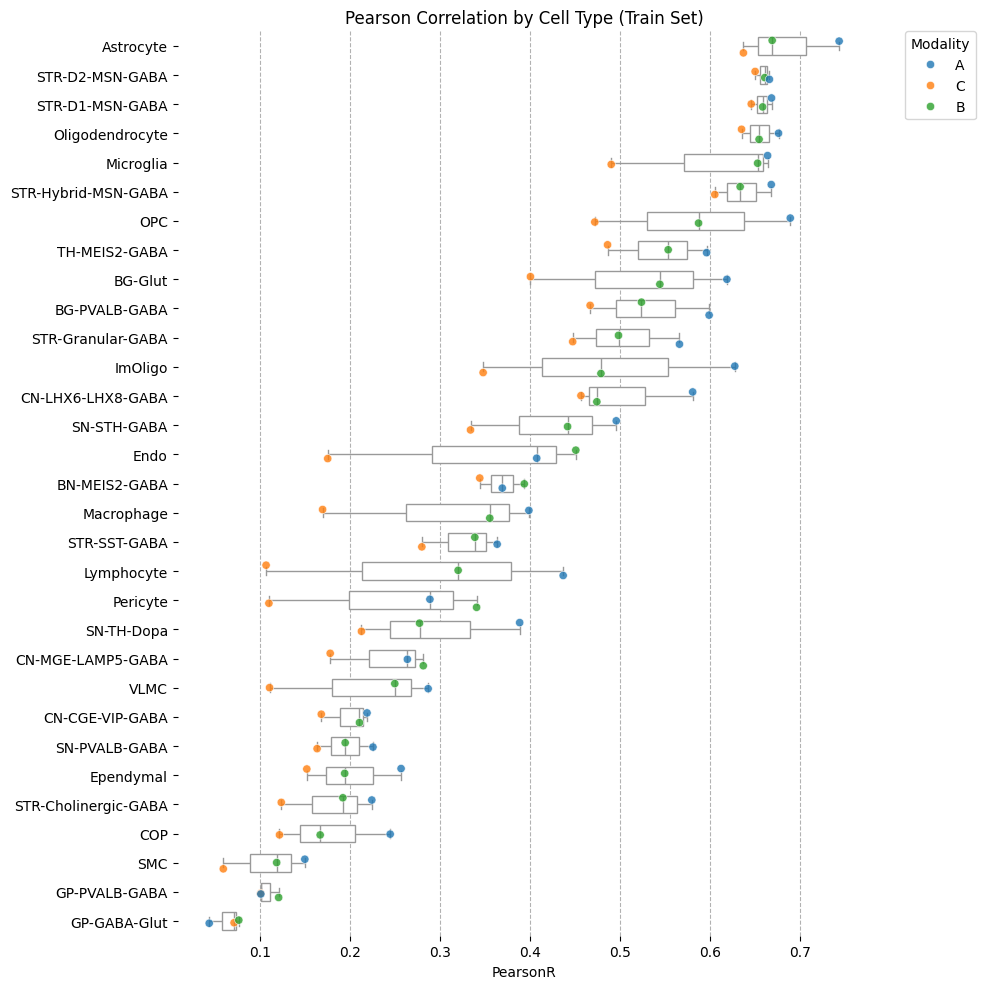

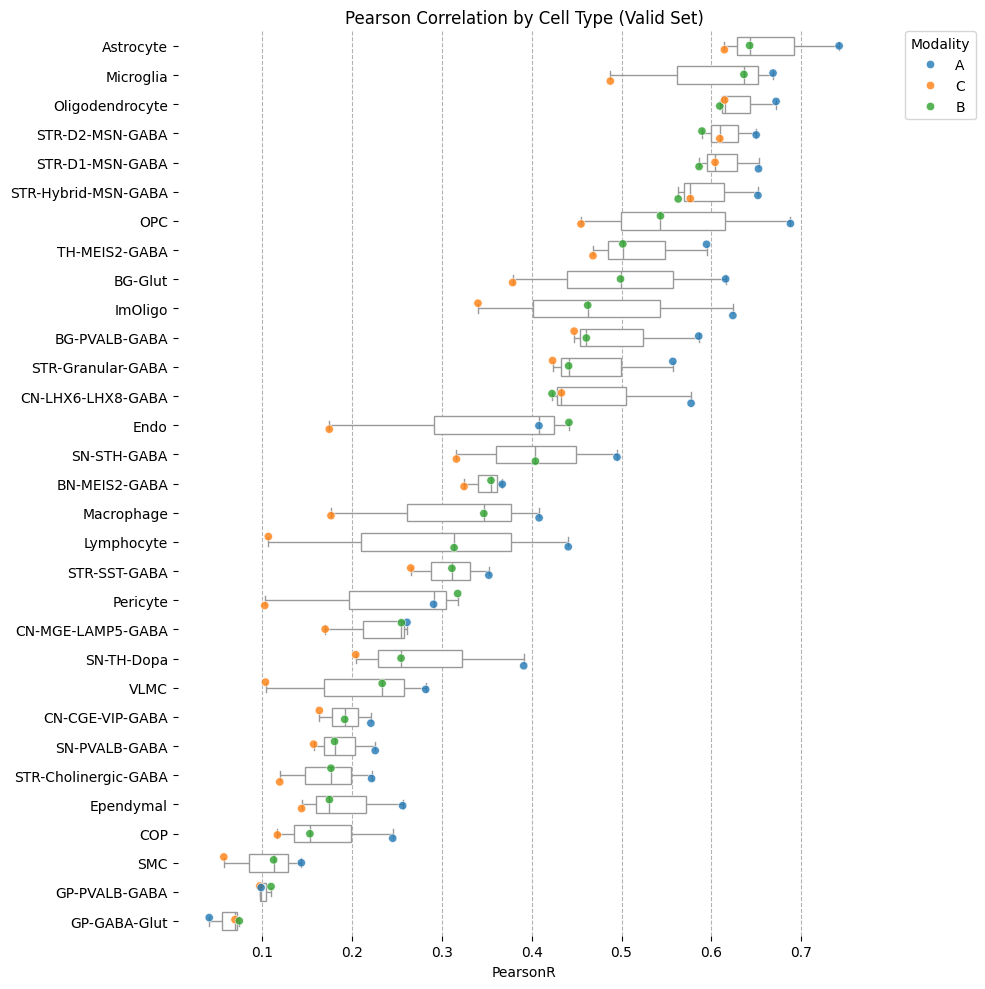

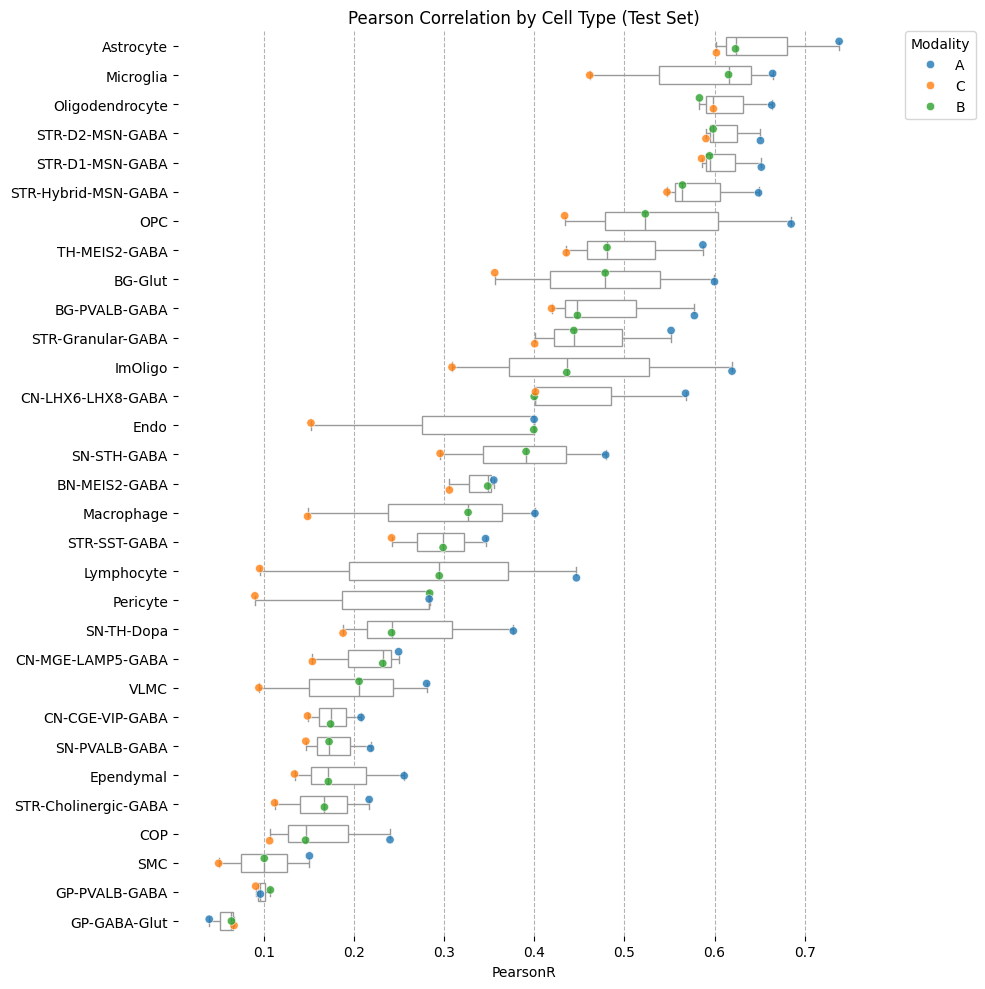

In [ ]:
for split in ["Train", "Valid", "Test"]:
    metric = pd.read_csv(f"{RES_BASE}/{exp_name}/analysis_{chk}/raw_data/{split}_metric.csv", index_col=0)
    metric["cell_type"] = metric.index.str.rsplit("_", n=0).str[0]
    metric["modality"] = metric.index.str.rsplit("_", n=0).str[-1]

    # Calculate median values and create x-positions as before
    median_values = (
        metric.groupby("cell_type")["PearsonR"].median().sort_values(ascending=False)
    )  # Note: ascending=True for horizontal plot
    celltype_to_x = {celltype: i for i, celltype in enumerate(median_values.index)}
    plot_df = metric.copy()
    plot_df["y_pos"] = plot_df["cell_type"].map(celltype_to_x)  # Using y_pos instead of x_pos

    n_modalities = len(plot_df["modality"].unique())
    selected_colors = [base_cmap(i) for i in range(0, base_cmap.N, 2)][:n_modalities]

    # Create figure with adjusted dimensions
    plt.figure(figsize=(10, 10))  # Wider and taller to accommodate horizontal layout

    # Create horizontal boxplot and stripplot
    sns.boxplot(y="y_pos", x="PearsonR", data=plot_df, color="white", width=0.6, orient="h")  # Horizontal orientation

    stripplot = sns.stripplot(
        y="y_pos",
        x="PearsonR",
        hue="modality",
        data=plot_df,
        palette=selected_colors,
        size=6,
        edgecolor="w",
        linewidth=0.5,
        alpha=0.8,
        jitter=0.25,
        orient="h",  # Horizontal orientation
    )

    # Customize y-axis to show cell type names
    plt.yticks(range(len(median_values)), median_values.index)
    plt.ylabel(None)
    plt.xlabel("PearsonR")

    # add grid line
    plt.grid(axis="x", linestyle="--", alpha=0.6, color="gray")
    sns.despine(left=True, bottom=True)

    # Adjust legend position (optional - may not be needed with y-axis labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, ncol=1, title="Modality")

    plt.title(f"Pearson Correlation by Cell Type ({split} Set)")
    plt.tight_layout()
    plt.savefig(
        f"{RES_BASE}/{exp_name}/analysis_{chk}/plot/{split}_pearsonr_by_cell_type.png",
        dpi=300,
        bbox_inches="tight",
    )

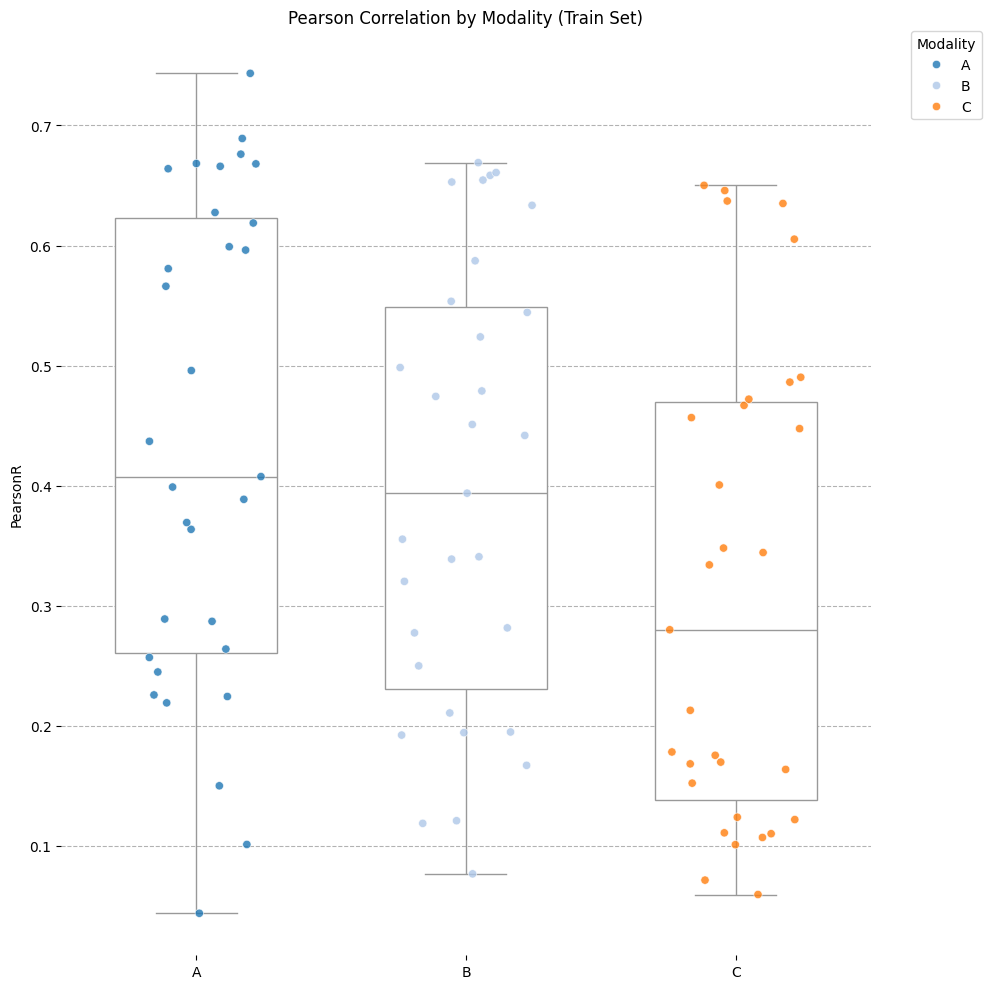

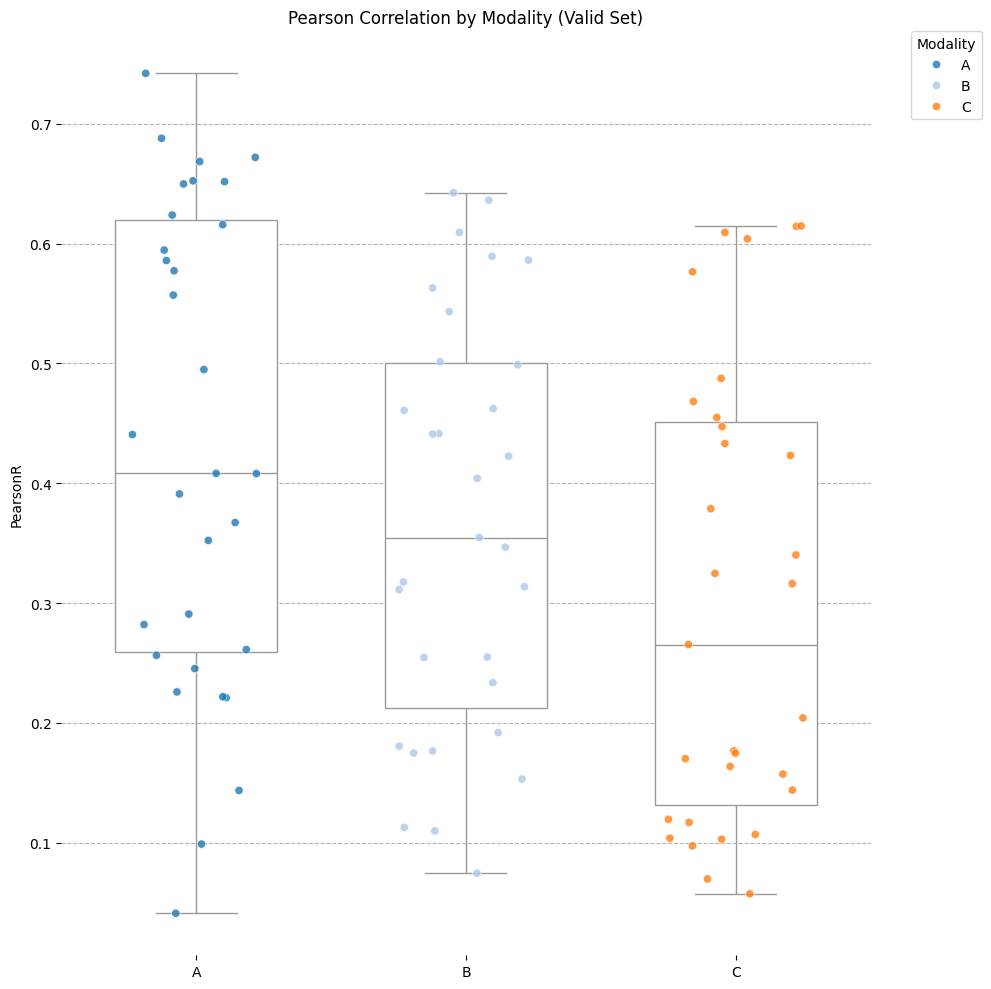

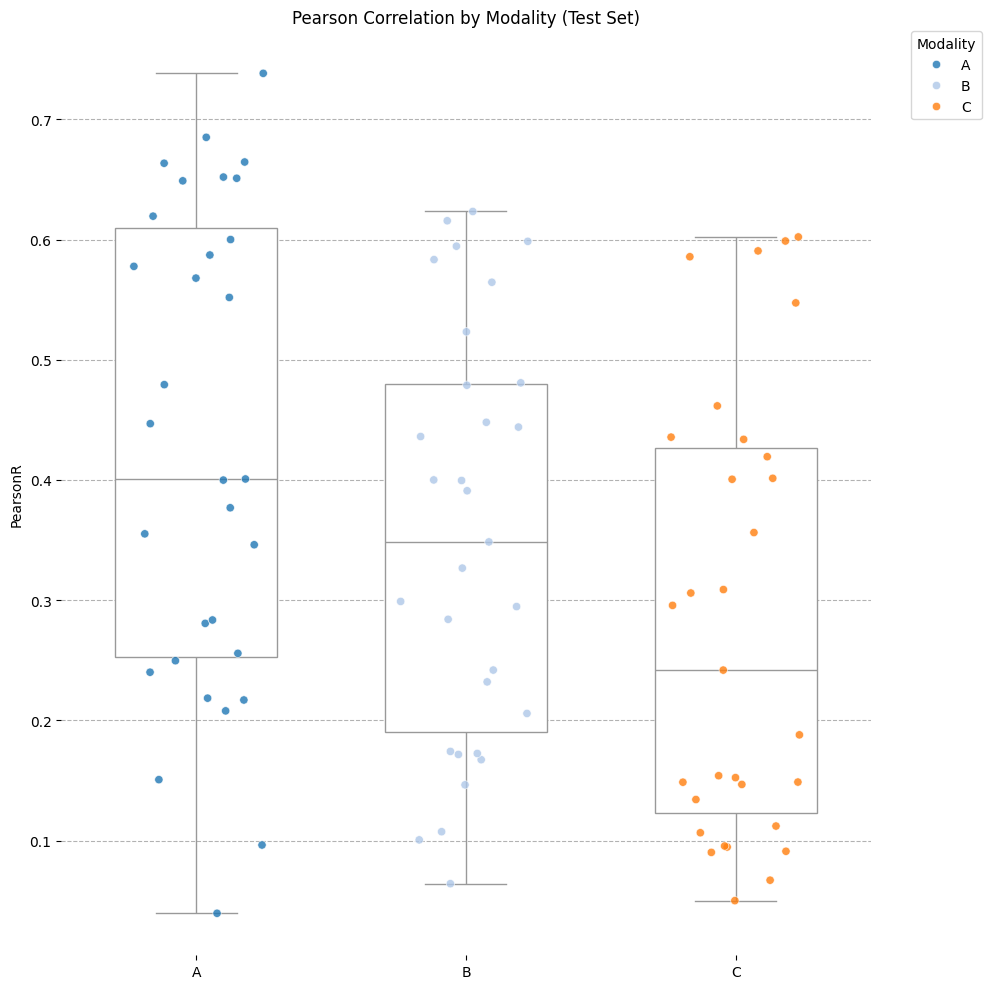

In [9]:
for split in ["Train", "Valid", "Test"]:
    metric = pd.read_csv(f"{RES_BASE}/{exp_name}/analysis_{chk}/raw_data/{split}_metric.csv", index_col=0)
    metric["cell_type"] = metric.index.str.rsplit("_", n=0).str[0]
    metric["modality"] = metric.index.str.rsplit("_", n=0).str[-1]

    # Calculate median values and create x-positions as before
    median_values = (
        metric.groupby("modality")["PearsonR"].median().sort_values(ascending=False)
    )  # Note: ascending=True for horizontal plot
    modality_to_x = {modality: i for i, modality in enumerate(median_values.index)}
    plot_df = metric.copy()
    plot_df["x_pos"] = plot_df["modality"].map(modality_to_x)

    # Create figure with adjusted dimensions
    plt.figure(figsize=(10, 10))  # Wider and taller to accommodate horizontal layout

    # Create horizontal boxplot and stripplot
    sns.boxplot(x="x_pos", y="PearsonR", data=plot_df, color="white", width=0.6)

    stripplot = sns.stripplot(
        x="x_pos",
        y="PearsonR",
        hue="modality",
        data=plot_df,
        palette="tab20",
        size=6,
        edgecolor="w",
        linewidth=0.5,
        alpha=0.8,
        jitter=0.25,
    )

    # Customize y-axis to show cell type names
    plt.xticks(range(len(median_values)), median_values.index)
    plt.xlabel(None)
    plt.ylabel("PearsonR")

    # add grid line
    plt.grid(axis="y", linestyle="--", alpha=0.6, color="gray")
    sns.despine(left=True, bottom=True)

    # Adjust legend position (optional - may not be needed with y-axis labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, ncol=1, title="Modality")

    plt.title(f"Pearson Correlation by Modality ({split} Set)")
    plt.tight_layout()
    plt.savefig(
        f"{RES_BASE}/{exp_name}/analysis_{chk}/plot/{split}_pearsonr_by_modality.png",
        dpi=300,
        bbox_inches="tight",
    )